# Exercise Sheet 04

**Discrete and Masked Image Models**  
This notebook contains one code cell per subtask. Complete the `# TODO` sections and keep your outputs visible before exporting the notebook as PDF.

This sheet has two main exercises:
1. VQ-VAE
2. Masked image modeling

We start with the VQ-VAE exercise below. The masked image modeling exercise will be added afterwards.

## General Setup

Run the next cell first. It loads the libraries and helper functions that are allowed for the VQ-VAE exercise.

The default dataset is Fashion-MNIST because it trains quickly on CPU. You may switch to another small image dataset if your implementation keeps the same tensor shapes expected by the model.

In [1]:
from pathlib import Path
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['image.cmap'] = 'gray'

DATA_ROOT = Path('./data')
BATCH_SIZE = 128
# Use 0 workers for robust notebook execution on shared/HPC file systems.
NUM_WORKERS = 0
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


def show_tensor_grid(images, title, nrow=8, value_range=(-1, 1)):
    """Display a batch of image tensors as a grid."""
    images = images.detach().cpu()
    grid = utils.make_grid(images, nrow=nrow, normalize=True, value_range=value_range)
    plt.figure(figsize=(8, 4))
    
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Using device: cuda


## Task 1: Vector-Quantized Variational Autoencoder

In this task you will implement and train a small VQ-VAE. The goal is to understand how an encoder can map images to continuous latent vectors, how a codebook discretizes those vectors, and how a decoder reconstructs images from the quantized representation.

The original VQ-VAE objective contains three important parts:
- reconstruction loss
- codebook loss
- commitment loss

### Task 1.1
Load Fashion-MNIST, normalize it to the range `[-1, 1]`, create train and test data loaders, and visualize one batch.

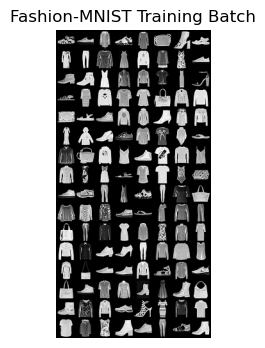

In [2]:
# TODO: Define a transform that converts images to tensors and normalizes them to [-1, 1].
# TODO: Create `train_dataset`, `test_dataset`, `train_loader`, and `test_loader`.
# TODO: Visualize a batch of training images with `show_tensor_grid`.

# Define a transform that converts images to tensors and normalizes them to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

# Create train_dataset and test_dataset
train_dataset = datasets.FashionMNIST(
    root=DATA_ROOT, 
    train=True, 
    download=True, 
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root=DATA_ROOT, 
    train=False, 
    download=True, 
    transform=transform
)

# Create train_loader and test_loader
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS
)

# Visualize a batch of training images with show_tensor_grid
images, labels = next(iter(train_loader))
show_tensor_grid(images, title="Fashion-MNIST Training Batch", value_range=(-1, 1))


### Task 1.2
Implement the encoder and decoder modules.

The layers are already defined for you in the code cell below. Complete the forward passes.

The encoder should map an input image of shape `(B, 1, 28, 28)` to a latent tensor of shape `(B, embedding_dim, 7, 7)`. The decoder should map the quantized latent tensor back to `(B, 1, 28, 28)` with values in `[-1, 1]`.


In [3]:
# TODO: Implement the encoder and decoder forward passes.

class Encoder(nn.Module):
    def __init__(self, in_channels=1, hidden_dim=64, embedding_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_dim, embedding_dim, kernel_size=3, stride=1, padding=1),
        )

    def forward(self, x):
        return self.net(x)


class Decoder(nn.Module):
    def __init__(self, out_channels=1, hidden_dim=64, embedding_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(embedding_dim, hidden_dim, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(hidden_dim, hidden_dim, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(hidden_dim, out_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),
        )

    def forward(self, z_q):
        return self.net(z_q)


### Task 1.3
Implement the vector quantizer.

For every latent vector, find the nearest codebook entry using squared Euclidean distance. Return:
- the straight-through quantized tensor `z_q`
- the VQ loss
- the integer code indices

Use the loss `codebook_loss + beta * commitment_loss`, where `beta = 0.25` by default.

The nearest-neighbor lookup is a discrete operation: it selects one codebook index with `argmin`. This hard assignment has no useful gradient for the encoder, because small changes in the encoder output usually keep the same nearest code selected. To still train the encoder from the reconstruction loss, use the straight-through estimator. In the forward pass it returns the quantized vector, but in the backward pass it behaves like an identity function so that gradients can pass through the encoder.

Hint: after computing the quantized tensor, use
`z_q = z_e + (z_q - z_e).detach()`.
The forward value is still `z_q`, while gradients flow through `z_e`.

The commitment loss encourages the encoder output to stay close to the selected codebook vector. This is important because the encoder could otherwise let the scale of its continuous outputs grow or move faster than the codebook can follow. The commitment term makes the encoder commit to nearby discrete codes and stabilizes training.


In [4]:
# TODO: Implement nearest-neighbor vector quantization.

class VectorQuantizer(nn.Module):
    def __init__(self, num_embeddings=128, embedding_dim=32, beta=0.25):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.beta = beta
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.uniform_(-1.0 / num_embeddings, 1.0 / num_embeddings)

    def forward(self, z_e):
        """Quantize encoder output `z_e` of shape (B, C, H, W)."""
        B, C, H, W = z_e.shape
        
        # 1. Flatten the spatial dimensions to shape (B*H*W, C)
        z_e_permuted = z_e.permute(0, 2, 3, 1).contiguous()
        z_e_flat = z_e_permuted.view(-1, self.embedding_dim)
        
        # 2. Compute squared Euclidean distances to all codebook entries
        # distance = ||z_e||^2 + ||e_k||^2 - 2 * z_e * e_k
        distances = (torch.sum(z_e_flat**2, dim=1, keepdim=True) 
                     + torch.sum(self.embedding.weight**2, dim=1)
                     - 2 * torch.matmul(z_e_flat, self.embedding.weight.t()))
                     
        # 3. Find the nearest codebook entry index (argmin)
        indices_flat = torch.argmin(distances, dim=1)
        
        # 4. Construct the quantized latent tensor and reshape back to (B, C, H, W)
        z_q_flat = self.embedding(indices_flat)
        z_q = z_q_flat.view(B, H, W, C).permute(0, 3, 1, 2).contiguous()
        
        # 5. Compute codebook loss and commitment loss
        codebook_loss = F.mse_loss(z_q, z_e.detach())
        commitment_loss = F.mse_loss(z_e, z_q.detach())
        vq_loss = codebook_loss + self.beta * commitment_loss
        
        # 6. Apply the straight-through estimator
        z_q = z_e + (z_q - z_e).detach()
        
        # Reshape indices to match the spatial dimensions (B, H, W)
        indices = indices_flat.view(B, H, W)
        
        return z_q, vq_loss, indices

### Task 1.4
Combine the encoder, quantizer, and decoder into a `VQVAE` module.

The model should return a dictionary with at least the following keys: `x_recon`, `vq_loss`, and `indices`.


In [5]:
# TODO: Implement the complete VQ-VAE model.

class VQVAE(nn.Module):
    def __init__(self, in_channels=1, hidden_dim=64, embedding_dim=32, num_embeddings=128, beta=0.25):
        super().__init__()
        self.encoder = Encoder(
            in_channels=in_channels, 
            hidden_dim=hidden_dim, 
            embedding_dim=embedding_dim
        )
        self.quantizer = VectorQuantizer(
            num_embeddings=num_embeddings, 
            embedding_dim=embedding_dim, 
            beta=beta
        )
        self.decoder = Decoder(
            out_channels=in_channels, # The output should match the input channels!
            hidden_dim=hidden_dim, 
            embedding_dim=embedding_dim
        )

    def forward(self, x):
        # 1. Pass the image through the encoder to get continuous latents
        z_e = self.encoder(x)
        
        # 2. Pass the continuous latents through the quantizer to get discrete codes
        z_q, vq_loss, indices = self.quantizer(z_e)
        
        # 3. Pass the discrete codes through the decoder to rebuild the image
        x_recon = self.decoder(z_q)
        
        # 4. Return the required outputs in a dictionary
        return {
            'x_recon': x_recon,
            'vq_loss': vq_loss,
            'indices': indices
        }


model = VQVAE().to(device)
print(model)
print(f'Trainable parameters: {count_parameters(model):,}')

VQVAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
  )
  (quantizer): VectorQuantizer(
    (embedding): Embedding(128, 32)
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): ConvTranspose2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): Tanh()
    )
  )
)
Trainable parameters: 174,369


### Task 1.5
Implement one training step.

Use mean squared error for the reconstruction loss. The total loss is `reconstruction_loss + vq_loss`.

In [6]:
# TODO: Implement `train_one_epoch`.

def train_one_epoch(model, loader, optimizer, epoch):
    model.train()
    total_loss = 0.0
    total_recon_loss = 0.0
    total_vq_loss = 0.0

    for images, _ in loader:
        images = images.to(device)

        optimizer.zero_grad()

        # 2. Forward pass: compute predicted outputs by passing inputs to the model
        outputs = model(images)
        x_recon = outputs['x_recon']
        vq_loss = outputs['vq_loss']

        # 3. Compute the reconstruction loss (Mean Squared Error)
        recon_loss = F.mse_loss(x_recon, images)

        # 4. Compute the total loss
        loss = recon_loss + vq_loss

        # 5. Backpropagate the errors and update the model parameters
        loss.backward()
        optimizer.step()

        # 6. Accumulate average metrics (.item() extracts the float value from the tensor)
        total_loss += loss.item()
        total_recon_loss += recon_loss.item()
        total_vq_loss += vq_loss.item()

    num_batches = len(loader)
    metrics = {
        'loss': total_loss / num_batches,
        'recon_loss': total_recon_loss / num_batches,
        'vq_loss': total_vq_loss / num_batches,
    }
    print(
        f"Epoch {epoch:02d} | loss={metrics['loss']:.4f} | "
        f"recon={metrics['recon_loss']:.4f} | vq={metrics['vq_loss']:.4f}"
    )
    return metrics


### Task 1.6
Train the VQ-VAE for a few epochs and plot the loss curves.

A small CPU run is enough for this sheet. If you have a GPU, you may increase the number of epochs.

Epoch 01 | loss=12.7771 | recon=0.2264 | vq=12.5507


Epoch 02 | loss=1.1074 | recon=0.0924 | vq=1.0150


Epoch 03 | loss=0.4001 | recon=0.0756 | vq=0.3245


Epoch 04 | loss=0.2341 | recon=0.0661 | vq=0.1680


Epoch 05 | loss=0.1640 | recon=0.0588 | vq=0.1052


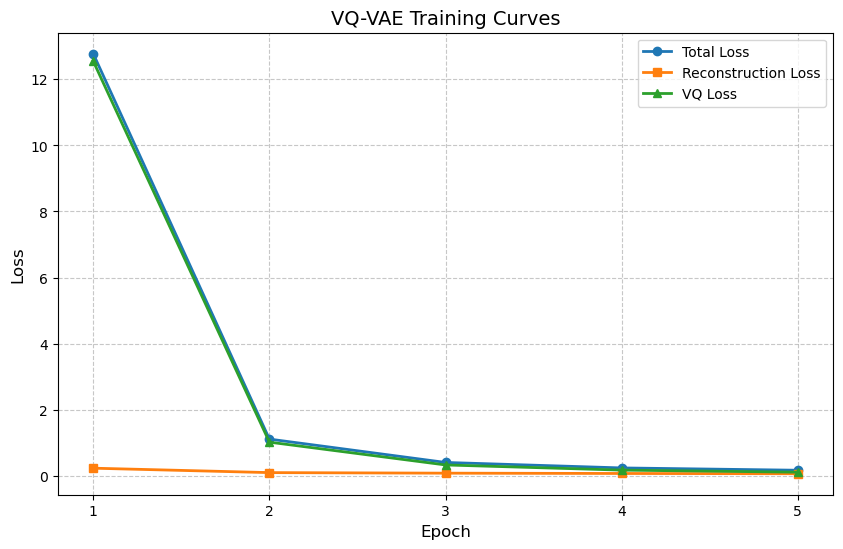

In [7]:
# TODO: Train the model and store the returned metrics in `history`.

NUM_EPOCHS = 5
LEARNING_RATE = 2e-4

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
history = []

# 1. Fill the training loop
for epoch in range(1, NUM_EPOCHS+ 1):
    # Call the training function we built in Task 1.5
    metrics = train_one_epoch(model, train_loader, optimizer, epoch)
    # Save the results so we can plot them later
    history.append(metrics)

# 2. Extract the data for plotting
epochs = range(1, NUM_EPOCHS + 1)
total_losses = [m['loss'] for m in history]
recon_losses = [m['recon_loss'] for m in history]
vq_losses = [m['vq_loss'] for m in history]

# 3. Plot the training curves
plt.figure(figsize=(10, 6))
plt.plot(epochs, total_losses, label='Total Loss', marker='o', linewidth=2)
plt.plot(epochs, recon_losses, label='Reconstruction Loss', marker='s', linewidth=2)
plt.plot(epochs, vq_losses, label='VQ Loss', marker='^', linewidth=2)

plt.title('VQ-VAE Training Curves', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(epochs) # Ensure the x-axis only shows whole integer epochs
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Task 1.7
Visualize reconstructions from the trained model.

Show original test images and their reconstructions in two separate grids. Briefly comment on which details are preserved and which details are lost.

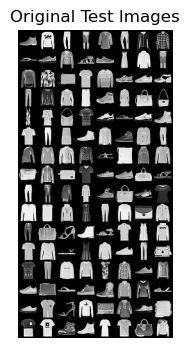

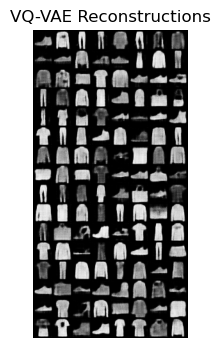


Preserved Details:
- general shapes and outlines
- brightness and greyscale

Not preserved:
- Details such as textures and patterns, for example the print on the T-shirts

The bottleneck mapps small differences to the same code, therefore closely related 
items loose theire differences entirely and look the same.



In [8]:
# Set the model to evaluation mode
model.eval()

# 1. Grab one batch of test images
images, _ = next(iter(test_loader))
images = images.to(device)

# 2. Run the model without tracking gradients (saves memory and speeds up computation)
with torch.no_grad():
    outputs = model(images)
    x_recon = outputs['x_recon']

# 3. Visualize the original images and the reconstructions
show_tensor_grid(images, title="Original Test Images", value_range=(-1, 1))
show_tensor_grid(x_recon, title="VQ-VAE Reconstructions", value_range=(-1, 1))

# 4. Briefly comment on reconstruction quality
reconstruction_comment = ("""
Preserved Details:
- general shapes and outlines
- brightness and greyscale
                          
Not preserved:
- Details such as textures and patterns, for example the print on the T-shirts
                          
The bottleneck mapps small differences to the same code, therefore closely related 
items loose theire differences entirely and look the same.
"""
)
print(reconstruction_comment)

### Task 1.8
Analyze the discrete latent codes.

Compute a histogram of codebook usage on the test set and report:
- how many codes were used at least once
- the most frequent code index

Then briefly explain what codebook collapse would look like in this histogram.


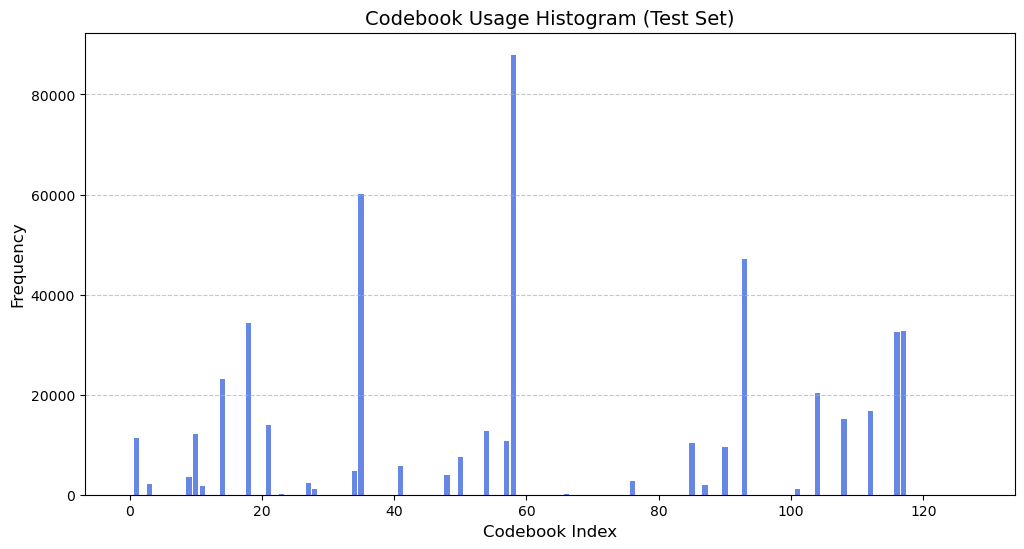

Codes used at least once: 39 / 128
Most frequent code index: 58 (Used 87,941 times)
--------------------------------------------------

Codebook collapse would happens when the modle becomes lazy and maps everything to only a small part of the availible embeddings.
The resulting histogram would only show a few large spikes spikes while the majority of the bins would remain empty because only a small 
percentage of the codebook is beeing used.



In [9]:
# TODO: Compute and plot codebook usage on the test set.

# 1. Set the model to evaluation mode
model.eval()

# 2. Collect all codebook indices used for the entire test set
all_indices = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model(images)
        # Flatten the (B, H, W) indices tensor into a 1D list and move to CPU
        all_indices.append(outputs['indices'].view(-1).cpu())

# 3. Combine all batches into one massive tensor of indices
all_indices = torch.cat(all_indices)

# 4. Count the frequency of each index
num_embeddings = model.quantizer.num_embeddings # Should be 128
usage_counts = torch.bincount(all_indices, minlength=num_embeddings).numpy()

# 5. Calculate the required metrics
num_used_codes = (usage_counts > 0).sum()
most_frequent_code = usage_counts.argmax()

# 6. Plot the histogram
plt.figure(figsize=(12, 6))
plt.bar(range(num_embeddings), usage_counts, color='royalblue', alpha=0.8)
plt.title('Codebook Usage Histogram (Test Set)', fontsize=14)
plt.xlabel('Codebook Index', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Print the requested reports
print(f"Codes used at least once: {num_used_codes} / {num_embeddings}")
print(f"Most frequent code index: {most_frequent_code} (Used {usage_counts[most_frequent_code]:,} times)")
print("-" * 50)

# 7. Explain codebook collapse
codebook_comment = ("""
Codebook collapse would happens when the modle becomes lazy and maps everything to only a small part of the availible embeddings.
The resulting histogram would only show a few large spikes spikes while the majority of the bins would remain empty because only a small 
percentage of the codebook is beeing used.
"""
)
print(codebook_comment)


### Task 1.9
Sample from the codebook.

Create a random grid of discrete code indices with the same spatial size as the encoder output, convert those indices to embeddings, decode them, and visualize the generated images. Comment on why these samples may look worse than reconstructions from real images.

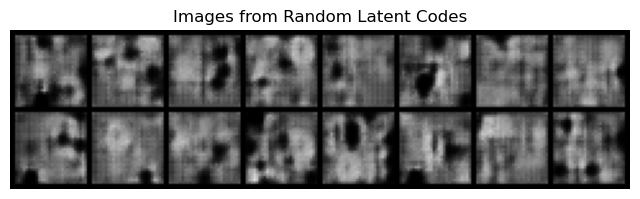

 
    Why Random Sampling Fails:
    - No Spatial Correllation: Real images have structure. Random patches ignore this, creating disjointed artifacts.
    - Need an Explicit Prior: We must train a seccond model (like a Transformer) to learn the visual grammer insted of just guessing.



In [10]:
# TODO: Sample random code indices, decode them, and visualize generated images.

# 1. Set the model to evaluation mode
model.eval()

# Define the shape of our latent space based on previous tasks
batch_size = 16
H, W = 7, 7 
num_embeddings = model.quantizer.num_embeddings

# 2. Create a random grid of discrete code indices
# We randomly pick integers between 0 and 127 for a batch of 7x7 grids
random_indices = torch.randint(low=0, high=num_embeddings, size=(batch_size, H, W)).to(device)

with torch.no_grad():
    # 3. Convert those indices to actual vector embeddings
    # The output shape will be (B, H, W, embedding_dim)
    z_q_random = model.quantizer.embedding(random_indices)
    
    # 4. Permute the dimensions to match what the Decoder expects: (B, C, H, W)
    z_q_random = z_q_random.permute(0, 3, 1, 2).contiguous()
    
    # 5. Decode the random embeddings into images
    generated_images = model.decoder(z_q_random)

# 6. Visualize the generated images
show_tensor_grid(generated_images, title="Images from Random Latent Codes", nrow=8, value_range=(-1, 1))

# 7. Explain why they look the way they do
sampling_comment = (""" 
    Why Random Sampling Fails:
    - No Spatial Correllation: Real images have structure. Random patches ignore this, creating disjointed artifacts.
    - Need an Explicit Prior: We must train a seccond model (like a Transformer) to learn the visual grammer insted of just guessing.
"""
)
print(sampling_comment)

## Task 2: Masked Image Modeling

In this task you will train a small model to reconstruct missing image regions. Instead of using a discrete codebook, the model receives an image with randomly masked patches and learns to predict the original pixels.

Use the Fashion-MNIST data loaders from Task 1. The reconstruction loss should be computed only on masked pixels.

### Task 2.1
Implement patch masking.

Given a batch of images of shape `(B, 1, 28, 28)`, create a binary mask with square patches of size `patch_size x patch_size`.

Your function should return two tensors:
- `masked_images`: the input images where masked pixels are replaced by `mask_value`
- `pixel_mask`: a binary tensor of shape `(B, 1, 28, 28)`, where `1` indicates masked pixels and `0` indicates visible pixels


In [13]:
def create_patch_mask(images, patch_size=7, mask_ratio=0.5, mask_value=0.0):
    B, C, H, W = images.shape
    num_patches_h = H // patch_size
    num_patches_w = W // patch_size
    num_patches = num_patches_h * num_patches_w
    num_masked = max(1, int(math.ceil(mask_ratio * num_patches)))

    # Build a flat patch-level mask for the whole batch: shape (B, num_patches)
    patch_mask = torch.zeros(B, num_patches, device=images.device)
    for i in range(B):
        # Randomly choose which patches to mask (without replacement)
        masked_indices = torch.randperm(num_patches, device=images.device)[:num_masked]
        patch_mask[i, masked_indices] = 1.0

    # Expand the patch mask to pixel level: reshape to (B, 1, H, W)
    # patch_mask shape: (B, num_patches_h, num_patches_w)
    patch_mask_2d = patch_mask.view(B, num_patches_h, num_patches_w)
    # Repeat each patch cell to fill patch_size x patch_size pixels
    pixel_mask = patch_mask_2d.repeat_interleave(patch_size, dim=1).repeat_interleave(patch_size, dim=2)
    pixel_mask = pixel_mask.unsqueeze(1)  # (B, 1, H, W)

    # Apply the mask: replace masked pixels with mask_value
    masked_images = images.clone()
    masked_images[pixel_mask.bool().expand_as(images)] = mask_value

    return masked_images, pixel_mask


### Task 2.2
Visualize masked inputs.

Apply your masking function to one test batch and visualize the original images, masked images, and binary masks for the mask ratios `0.25`, `0.5`, and `0.75`. Briefly describe the effect of the mask ratio.

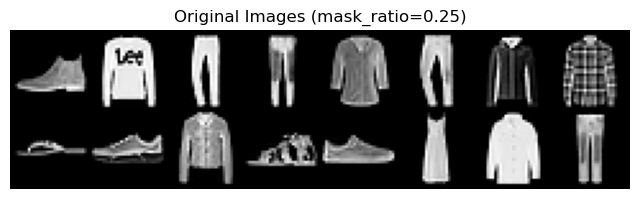

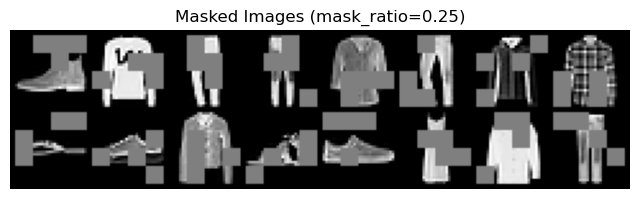

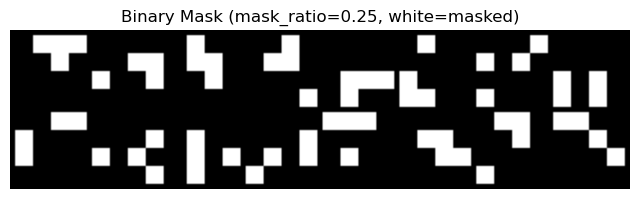

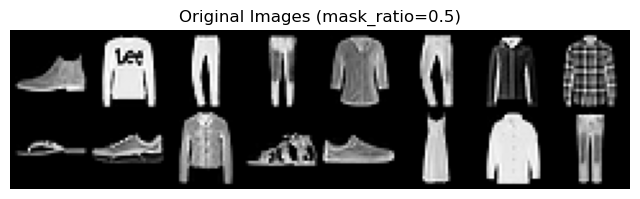

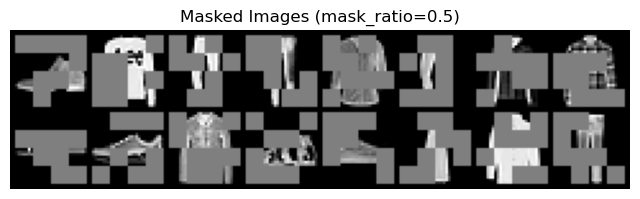

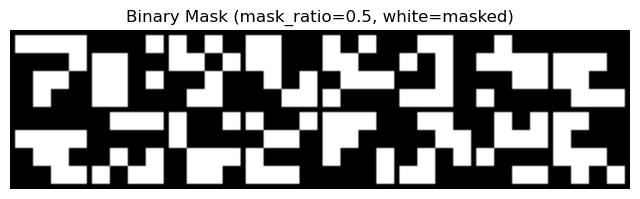

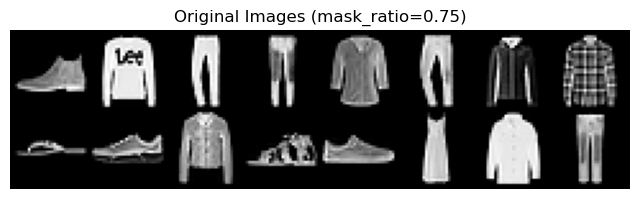

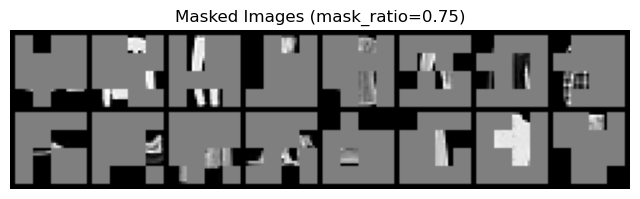

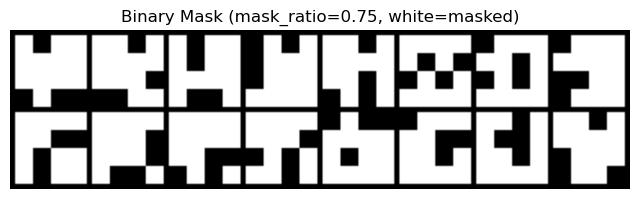

 
    Effect of mask ratio: as the mask ratio increases, more patches are hidden. 
    At 0.25, roughly a quarter of patches are masked, leaving most of the image visible. 
    At 0.5, half the image is gone, making reconstruction noticeably harder. 
    At 0.75, only a quarter of pixels remain, and the model has very little context to work with.



In [14]:
images, _ = next(iter(test_loader))
images = images.to(device)

for ratio in [0.25, 0.5, 0.75]:
    masked_imgs, pixel_mask = create_patch_mask(images, patch_size=7, mask_ratio=ratio)

    show_tensor_grid(images[:16], title=f"Original Images (mask_ratio={ratio})", value_range=(-1, 1))
    show_tensor_grid(masked_imgs[:16], title=f"Masked Images (mask_ratio={ratio})", value_range=(-1, 1))
    # pixel_mask is binary {0,1}, display with value_range=(0,1)
    show_tensor_grid(pixel_mask[:16].float(), title=f"Binary Mask (mask_ratio={ratio}, white=masked)", value_range=(0, 1))

mask_ratio_comment = (""" 
    Effect of mask ratio: as the mask ratio increases, more patches are hidden. 
    At 0.25, roughly a quarter of patches are masked, leaving most of the image visible. 
    At 0.5, half the image is gone, making reconstruction noticeably harder. 
    At 0.75, only a quarter of pixels remain, and the model has very little context to work with.
"""
)
print(mask_ratio_comment)


### Task 2.3
Implement a small masked image modeling network.

The layers are already defined for you in the code cell below. Complete the forward pass.

The model should map a masked image of shape `(B, 1, 28, 28)` back to a reconstructed image of the same shape. The final activation matches the image range `[-1, 1]`.


In [13]:
class MaskedConvAutoencoder(nn.Module):
    def __init__(self, in_channels=1, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(hidden_dim, hidden_dim, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(hidden_dim, in_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),
        )

    def forward(self, x_masked):
        return self.net(x_masked)


mim_model = MaskedConvAutoencoder().to(device)
print(mim_model)
print(f'Trainable parameters: {count_parameters(mim_model):,}')


MaskedConvAutoencoder(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): Tanh()
  )
)
Trainable parameters: 170,241


### Task 2.4
Train the masked image model.

For every batch, create a fresh random patch mask. Feed the masked image into the model and compute mean squared error only on masked pixels. Train for a few epochs and plot the training loss.

Epoch 01 | masked reconstruction loss=0.2199


Epoch 02 | masked reconstruction loss=0.1573


Epoch 03 | masked reconstruction loss=0.1415


Epoch 04 | masked reconstruction loss=0.1334


Epoch 05 | masked reconstruction loss=0.1276


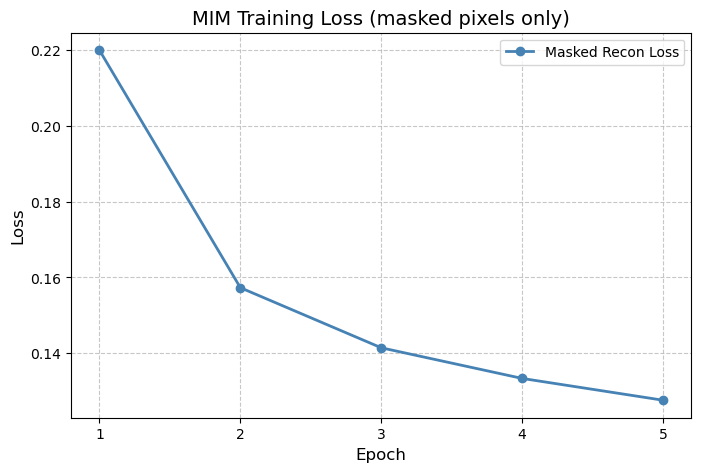

In [14]:
def masked_mse_loss(prediction, target, pixel_mask):
    """Mean squared error computed only on masked pixels."""
    squared_error = (prediction - target) ** 2
    # Multiply by mask so only masked pixels contribute, then average over them
    masked_error = squared_error * pixel_mask
    return masked_error.sum() / pixel_mask.sum()


def train_mim_one_epoch(model, loader, optimizer, epoch, patch_size=7, mask_ratio=0.5):
    model.train()
    total_loss = 0.0

    for images, _ in loader:
        images = images.to(device)

        # Create a fresh random patch mask for this batch
        masked_images, pixel_mask = create_patch_mask(images, patch_size=patch_size, mask_ratio=mask_ratio)

        optimizer.zero_grad()

        # Reconstruct the full image from the masked input
        prediction = model(masked_images)

        # Loss only on the masked pixels
        loss = masked_mse_loss(prediction, images, pixel_mask)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    print(f'Epoch {epoch:02d} | masked reconstruction loss={avg_loss:.4f}')
    return avg_loss


MIM_NUM_EPOCHS = 5
MIM_LEARNING_RATE = 2e-4
MIM_MASK_RATIO = 0.5

mim_optimizer = torch.optim.Adam(mim_model.parameters(), lr=MIM_LEARNING_RATE)
mim_history = []

for epoch in range(1, MIM_NUM_EPOCHS + 1):
    avg_loss = train_mim_one_epoch(mim_model, train_loader, mim_optimizer, epoch, mask_ratio=MIM_MASK_RATIO)
    mim_history.append(avg_loss)

# Plot the masked reconstruction loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, MIM_NUM_EPOCHS + 1), mim_history, marker='o', linewidth=2, color='steelblue', label='Masked Recon Loss')
plt.title('MIM Training Loss (masked pixels only)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(range(1, MIM_NUM_EPOCHS + 1))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


### Task 2.5
Evaluate reconstructions.

Visualize original images, masked images, and reconstructions from the trained model for the mask ratios `0.25`, `0.5`, and `0.75`. Compare the reconstructions for the three mask ratios and explain why reconstruction becomes harder as more patches are masked.

In [ ]:
mim_model.eval()
images, _ = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    for ratio in [0.25, 0.5, 0.75]:
        masked_imgs, pixel_mask = create_patch_mask(images, patch_size=7, mask_ratio=ratio)
        reconstruction = mim_model(masked_imgs)

        # Composite: fill visible pixels from original, masked pixels from reconstruction
        completed = images.clone()
        completed[pixel_mask.bool().expand_as(images)] = reconstruction[pixel_mask.bool().expand_as(images)]

        show_tensor_grid(images[:16], title=f"Originals (mask_ratio={ratio})", value_range=(-1, 1))
        show_tensor_grid(masked_imgs[:16], title=f"Masked Input (mask_ratio={ratio})", value_range=(-1, 1))
        show_tensor_grid(reconstruction[:16], title=f"Full Reconstruction (mask_ratio={ratio})", value_range=(-1, 1))
        show_tensor_grid(completed[:16], title=f"Completed Image — visible pixels from original (mask_ratio={ratio})", value_range=(-1, 1))

mim_reconstruction_comment = (""" 
    Effect of mask ratio on reconstruction quality:
    - mask_ratio=0.25: The model sees 75% of the image and can easily guess the missing parts 
    from surrounding context. Reconstructions are sharp and closely match the originals.
    - mask_ratio=0.5: With half the image hidden, the model must extrapolate more aggressively. 
    General shapes and contrast are preserved, but fine details such as textures and patterns begin to blur.
    - mask_ratio=0.75: Only 25% of pixels are visible, leaving the model with very little context. 
    Reconstructions capture broad structure at best and often produce blurry or averaged-out patches, 
    because many valid completions exist and the model defaults to a mean-like estimate over them.
                              
    The main reason reconstruction degrades with more masking is that 
    each additional hidden patch removes context that neighbouring patches rely on. 
    With very high mask ratios the local receptive field of the convolutional encoder 
    may contain almost no visible signal, so the model cannot recover fine details.
"""
)
print(mim_reconstruction_comment)


NameError: name 'mim_model' is not defined

## Submission Reminder

Before submission, make sure that:
- all `# TODO` sections are completed,
- all requested plots are visible in the notebook output,
- all short written answers are filled in,
- the notebook is exported as PDF,
- the `.ipynb` and PDF are included in the ZIP file following the naming convention from the sheet.